In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── MOCK DATA (same as Notebook 1)
np.random.seed(42)
comp = pd.DataFrame({
    'company_id': range(1, 101),
    'company_name': [f"Company_{i}" for i in range(1, 101)],
    'sector': np.random.choice(['IT','Banking','FMCG','Pharma','Auto','Energy'], 100),
    'roe_percentage': np.random.uniform(5, 40, 100)
})
pl = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'sales': np.random.uniform(500, 50000, 1000),
    'net_profit': np.random.uniform(50, 8000, 1000),
    'opm_pct': np.random.uniform(5, 35, 1000),
    'dividend_payout_pct': np.random.uniform(0, 60, 1000),
})
bs = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'debt_to_equity': np.random.uniform(0, 3, 1000),
})
cf = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'operating_activity': np.random.uniform(-500, 12000, 1000),
})
ana = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 3),
    'metric': np.tile(['compounded_sales_growth'], 300),
    'period_label': np.tile(['3Y', '5Y', '10Y'], 100),
    'value_pct': np.random.uniform(-5, 30, 300),
})

print("✅ Data loaded — ready for scoring!")

✅ Data loaded — ready for scoring!


In [26]:
# Step 1 — Company level summary metrics
# Profitability
profitability = pl.groupby('company_id').agg(
    avg_opm=('opm_pct', 'mean'),
    avg_net_margin=('net_profit', lambda x: (x / pl.loc[x.index, 'sales'] * 100).mean()),
    avg_roe=('net_profit', 'mean')
).reset_index()
profitability = profitability.merge(comp[['company_id', 'roe_percentage']], on='company_id', how='left')

# Revenue Growth
cagr3 = ana[(ana['metric'] == 'compounded_sales_growth') & (ana['period_label'] == '3Y')]
cagr3 = cagr3[['company_id', 'value_pct']].rename(columns={'value_pct': 'cagr_3y'})

# Leverage
leverage = bs.groupby('company_id').agg(
    latest_de=('debt_to_equity', 'last')
).reset_index()

# Cash Flow
cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
cashflow = cf_pl.groupby('company_id').agg(avg_ccr=('ccr', 'mean')).reset_index()

# Dividend
dividend = pl.groupby('company_id').agg(
    avg_dividend=('dividend_payout_pct', 'mean')
).reset_index()

# Trend slope (linear regression on last 5 years sales)
def trend_slope(series):
    s = series.dropna().values[-5:]
    if len(s) < 2: return 0
    return np.polyfit(range(len(s)), s, 1)[0]

trend = pl.groupby('company_id')['sales'].apply(trend_slope).reset_index()
trend.columns = ['company_id', 'trend_slope']

# Merge all
metrics = comp[['company_id', 'company_name', 'sector']].copy()
metrics = metrics.merge(profitability[['company_id', 'avg_opm', 'roe_percentage']], on='company_id', how='left')
metrics = metrics.merge(cagr3, on='company_id', how='left')
metrics = metrics.merge(leverage, on='company_id', how='left')
metrics = metrics.merge(cashflow, on='company_id', how='left')
metrics = metrics.merge(dividend, on='company_id', how='left')
metrics = metrics.merge(trend, on='company_id', how='left')

print(f"✅ Metrics ready — {metrics.shape[0]} companies, {metrics.shape[1]} columns")
display(metrics.head())


✅ Metrics ready — 100 companies, 10 columns


,company_id,company_name,sector,avg_opm,roe_percentage,cagr_3y,latest_de,avg_ccr,avg_dividend,trend_slope
0,1,Company_1,Pharma,17.772890,33.076894,29.529932,1.748143,3.112267,20.611369,1512.522066
1,2,Company_2,Auto,20.502350,7.609273,-3.151094,0.384978,2.326350,28.486675,-2139.875810
2,3,Company_3,FMCG,21.909665,39.541043,24.275391,0.077069,3.290534,37.643756,-3132.442364
3,4,Company_4,Auto,20.845173,32.028567,14.655808,1.756691,9.410355,35.126490,-4997.873823
4,5,Company_5,Auto,24.385497,11.955049,6.158606,0.124737,2.612371,24.106565,-3168.709556


In [27]:
# Step 2 — Scoring functions (Section 7.1)

def score_profitability(df):
    # Percentile rank, scaled 0-25
    return df['avg_opm'].rank(pct=True) * 25

def score_revenue_growth(df):
    # <5% = 0, scales to 20 at 20%+
    return df['cagr_3y'].fillna(0).apply(
        lambda x: 0 if x < 5 else min((x / 20) * 20, 20)
    )

def score_leverage(df):
    # D/E < 0.1 = full 20, D/E > 2 = 0, linear between
    return ((1 - df['latest_de'].clip(0, 2) / 2) * 20).clip(0, 20)

def score_cashflow(df):
    # CCR > 1.2 = full 15
    return df['avg_ccr'].fillna(0).apply(
        lambda x: min(x / 1.2 * 15, 15)
    ).clip(0, 15)

def score_dividend(df):
    # avg payout > 30% = full 10
    return df['avg_dividend'].fillna(0).apply(
        lambda x: min(x / 30 * 10, 10)
    ).clip(0, 10)

def score_growth_trend(df):
    # Positive slope = 10, negative = 0
    return df['trend_slope'].apply(lambda x: 10 if x > 0 else 0)

def get_health_label(score):
    if score >= 85: return 'EXCELLENT'
    if score >= 70: return 'GOOD'
    if score >= 50: return 'AVERAGE'
    if score >= 35: return 'WEAK'
    return 'POOR'

print("✅ Scoring functions defined!")

✅ Scoring functions defined!


In [28]:
# Step 3 — Compute final scores
metrics['score_profitability']    = score_profitability(metrics)
metrics['score_revenue_growth']   = score_revenue_growth(metrics)
metrics['score_leverage']         = score_leverage(metrics)
metrics['score_cashflow']         = score_cashflow(metrics)
metrics['score_dividend']         = score_dividend(metrics)
metrics['score_growth_trend']     = score_growth_trend(metrics)

metrics['overall_score'] = (
    metrics['score_profitability'] +
    metrics['score_revenue_growth'] +
    metrics['score_leverage'] +
    metrics['score_cashflow'] +
    metrics['score_dividend'] +
    metrics['score_growth_trend']
)

metrics['health_label'] = metrics['overall_score'].apply(get_health_label)

print("Score distribution:")
print(metrics['health_label'].value_counts())
print(f"\nAvg score : {metrics['overall_score'].mean():.1f}")
print(f"Max score : {metrics['overall_score'].max():.1f}")
print(f"Min score : {metrics['overall_score'].min():.1f}")
display(metrics[['company_name', 'sector', 'overall_score', 'health_label']].sort_values('overall_score', ascending=False).head(10))

Score distribution:
health_label
AVERAGE      50
WEAK         23
GOOD         21
EXCELLENT     3
POOR          3
Name: count, dtype: int64

Avg score : 59.8
Max score : 91.6
Min score : 28.8


,company_name,sector,overall_score,health_label
63,Company_64,Energy,91.583648,EXCELLENT
78,Company_79,Pharma,89.029397,EXCELLENT
15,Company_16,Pharma,86.871977,EXCELLENT
58,Company_59,Pharma,83.785997,GOOD
62,Company_63,FMCG,83.049164,GOOD
2,Company_3,FMCG,81.979311,GOOD
36,Company_37,Energy,81.275975,GOOD
20,Company_21,Auto,80.016477,GOOD
27,Company_28,IT,79.823243,GOOD
6,Company_7,FMCG,79.457218,GOOD


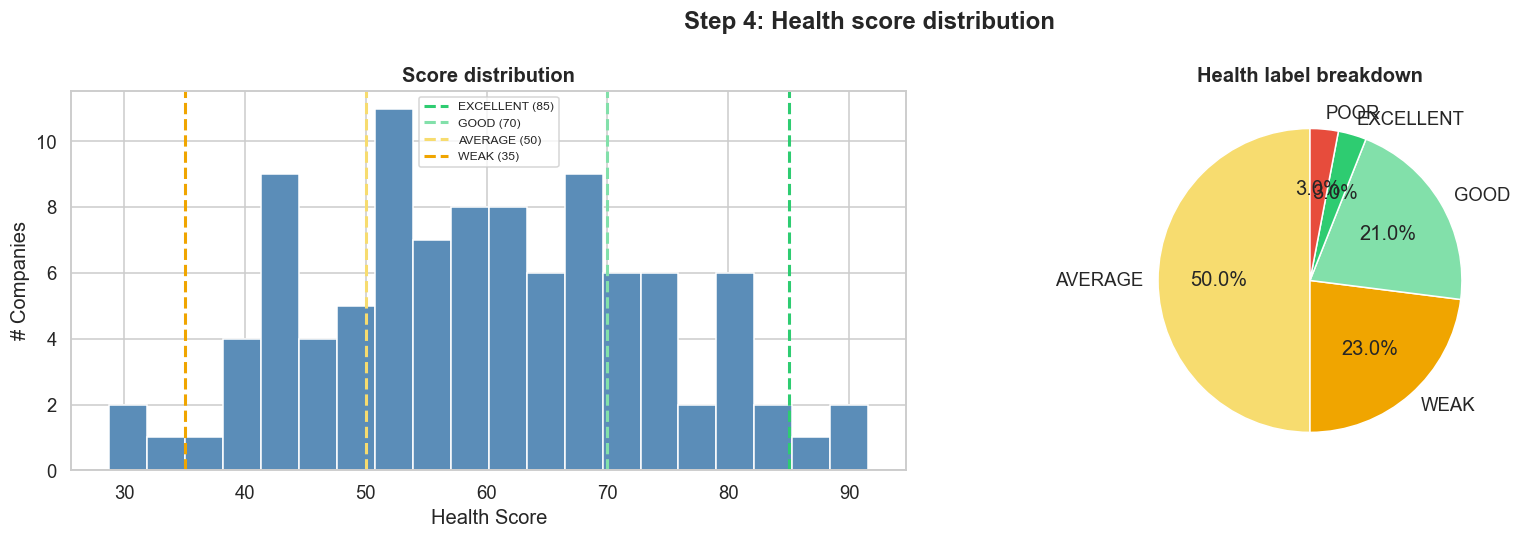

In [29]:
# Step 4 — Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score histogram
axes[0].hist(metrics['overall_score'], bins=20, color='#5B8DB8', edgecolor='white')
axes[0].axvline(85, color='#2ECC71', lw=2, linestyle='--', label='EXCELLENT (85)')
axes[0].axvline(70, color='#82E0AA', lw=2, linestyle='--', label='GOOD (70)')
axes[0].axvline(50, color='#F7DC6F', lw=2, linestyle='--', label='AVERAGE (50)')
axes[0].axvline(35, color='#F0A500', lw=2, linestyle='--', label='WEAK (35)')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('# Companies')
axes[0].set_title('Score distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# Label pie chart
label_counts = metrics['health_label'].value_counts()
colors = {'EXCELLENT': '#2ECC71', 'GOOD': '#82E0AA', 'AVERAGE': '#F7DC6F',
          'WEAK': '#F0A500', 'POOR': '#E74C3C'}
pie_colors = [colors.get(l, '#CCCCCC') for l in label_counts.index]
axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=pie_colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Health label breakdown', fontweight='bold')

plt.suptitle('Step 4: Health score distribution', fontweight='bold')
plt.tight_layout()
plt.show()

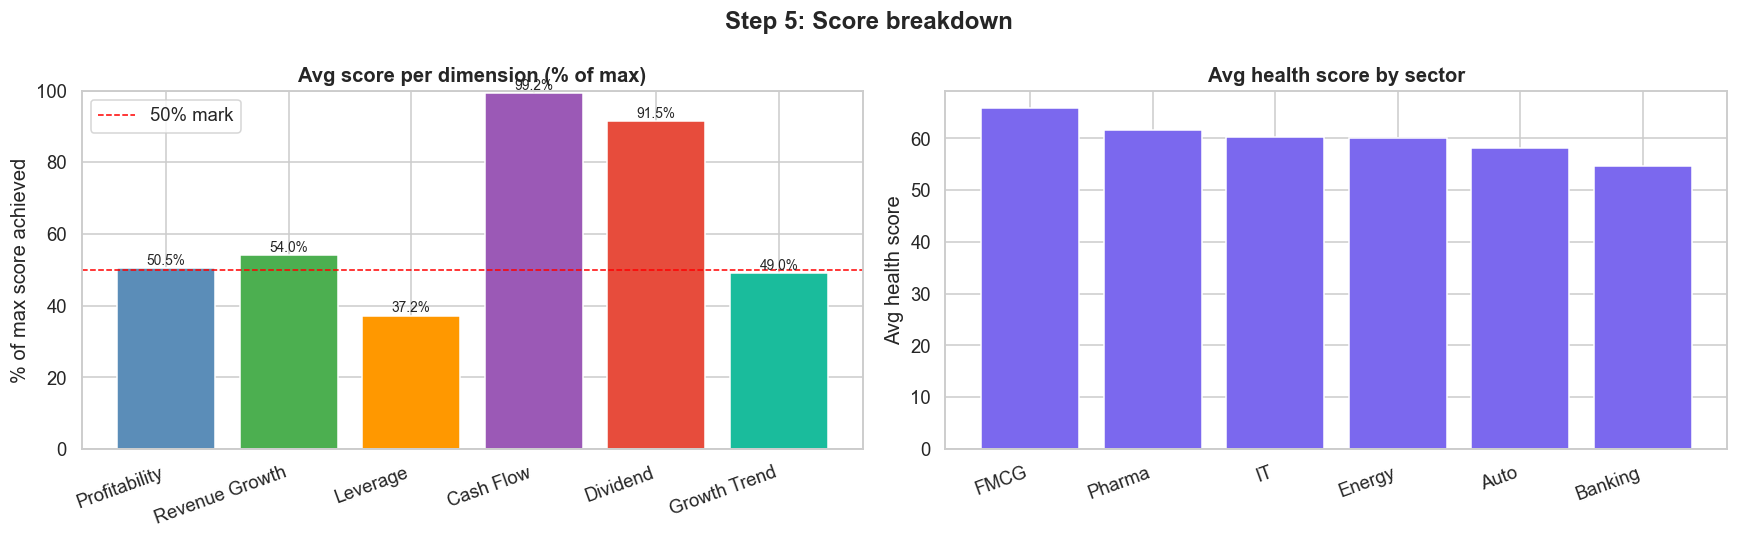

In [30]:
# Step 5 — Avg score per dimension
score_cols = ['score_profitability', 'score_revenue_growth', 'score_leverage',
              'score_cashflow', 'score_dividend', 'score_growth_trend']
max_scores = [25, 20, 20, 15, 10, 10]
labels     = ['Profitability', 'Revenue Growth', 'Leverage', 'Cash Flow', 'Dividend', 'Growth Trend']

avg_scores = metrics[score_cols].mean().values
pct_scores = [a/m*100 for a, m in zip(avg_scores, max_scores)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(labels, pct_scores,
                   color=['#5B8DB8','#4CAF50','#FF9800','#9B59B6','#E74C3C','#1ABC9C'],
                   edgecolor='white')
axes[0].set_ylabel('% of max score achieved')
axes[0].set_ylim(0, 100)
axes[0].axhline(50, color='red', lw=1, linestyle='--', label='50% mark')
axes[0].set_xticklabels(labels, rotation=20, ha='right')
axes[0].set_title('Avg score per dimension (% of max)', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, pct_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9)

# Score by sector
sector_scores = metrics.groupby('sector')['overall_score'].mean().sort_values(ascending=False)
axes[1].bar(sector_scores.index, sector_scores.values, color='#7B68EE', edgecolor='white')
axes[1].set_ylabel('Avg health score')
axes[1].set_title('Avg health score by sector', fontweight='bold')
axes[1].set_xticklabels(sector_scores.index, rotation=20, ha='right')

plt.suptitle('Step 5: Score breakdown', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Step 6 — Cross validation
validate = ['Company_1', 'Company_5', 'Company_10', 'Company_50', 'Company_99']
val_df = metrics[metrics['company_name'].isin(validate)][
    ['company_name', 'overall_score', 'health_label',
     'score_profitability', 'score_revenue_growth',
     'score_leverage', 'score_cashflow', 'score_dividend']
].round(2)

print("Cross-validation — known companies:")
display(val_df)

# When real DB is ready, replace validate list with:
# ['TCS', 'HDFCBANK', 'WIPRO', 'ADANIPOWER', 'APOLLOHOSP']

Cross-validation — known companies:


,company_name,overall_score,health_label,score_profitability,score_revenue_growth,score_leverage,score_cashflow,score_dividend
0,Company_1,60.39,AVERAGE,6.00,20.00,2.52,15.0,6.87
4,Company_5,71.70,GOOD,23.75,6.16,18.75,15.0,8.04
9,Company_10,71.48,GOOD,18.75,19.22,0.55,15.0,7.96
49,Company_50,53.51,AVERAGE,11.75,0.00,16.84,15.0,9.92
98,Company_99,77.30,GOOD,21.00,19.01,14.48,15.0,7.81


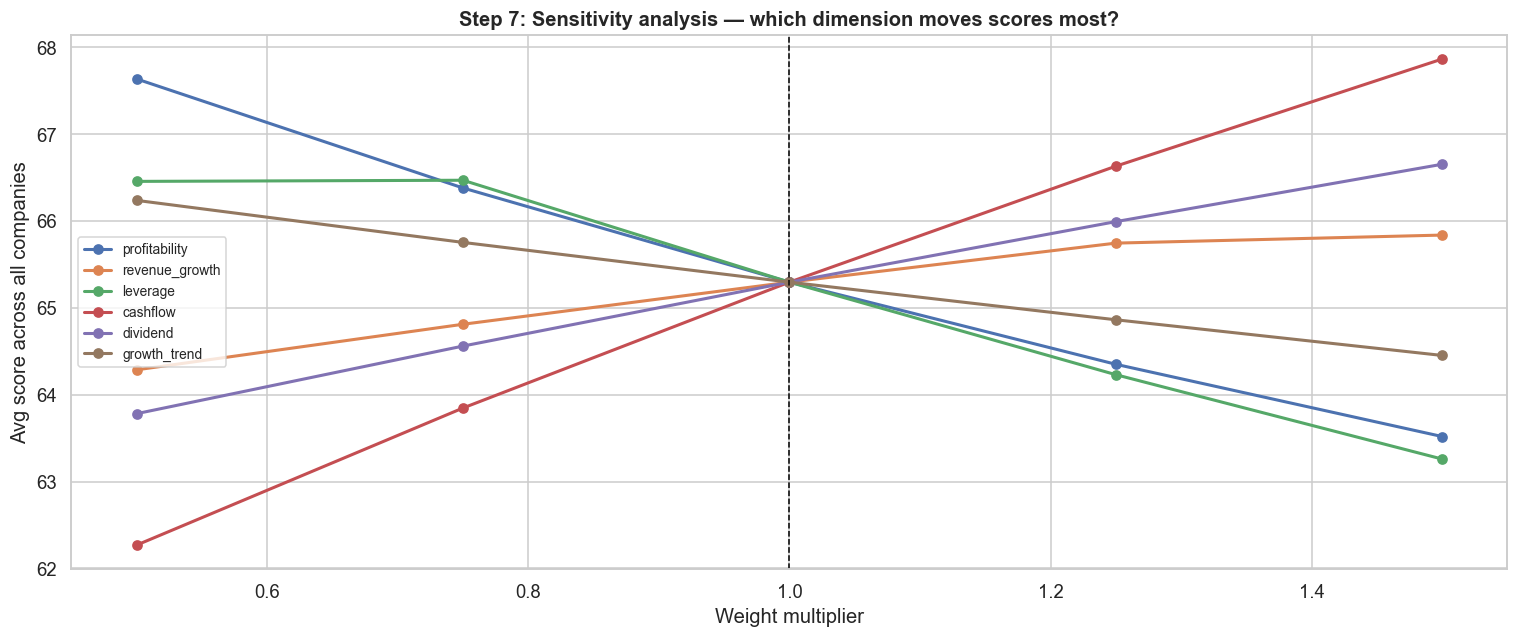


Most impactful dimension:
dimension
cashflow          2.211585
profitability     1.627582
leverage          1.403767
dividend          1.134745
growth_trend      0.705492
revenue_growth    0.651510
Name: avg_score, dtype: float64


In [32]:
# Step 7 — Sensitivity analysis
# How much does changing each weight change the final score?

base_weights = {
    'score_profitability':  1.0,
    'score_revenue_growth': 1.0,
    'score_leverage':       1.0,
    'score_cashflow':       1.0,
    'score_dividend':       1.0,
    'score_growth_trend':   1.0
}

results = []

for col in base_weights:
    for multiplier in [0.5, 0.75, 1.0, 1.25, 1.5]:
        weights = base_weights.copy()
        weights[col] = multiplier
        
        test_score = sum(metrics[c] * weights[c] for c in base_weights)
        # Normalize back to 0-100
        test_score = test_score / test_score.max() * 100
        
        results.append({
            'dimension': col.replace('score_', ''),
            'weight_multiplier': multiplier,
            'avg_score': test_score.mean(),
            'std_score': test_score.std()
        })

sens_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(14, 6))
for dim in sens_df['dimension'].unique():
    d = sens_df[sens_df['dimension'] == dim]
    ax.plot(d['weight_multiplier'], d['avg_score'],
            marker='o', label=dim, lw=2)

ax.set_xlabel('Weight multiplier')
ax.set_ylabel('Avg score across all companies')
ax.set_title('Step 7: Sensitivity analysis — which dimension moves scores most?', fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(1.0, color='black', lw=1, linestyle='--', label='Base weight')
plt.tight_layout()
plt.show()

print("\nMost impactful dimension:")
impact = sens_df.groupby('dimension')['avg_score'].std().sort_values(ascending=False)
print(impact)

In [33]:
# Step 8 — Export scores to CSV
import os
os.makedirs('../data/processed', exist_ok=True)

export_cols = [
    'company_id', 'company_name', 'sector', 'overall_score', 'health_label',
    'score_profitability', 'score_revenue_growth', 'score_leverage',
    'score_cashflow', 'score_dividend', 'score_growth_trend'
]

metrics[export_cols].round(2).to_csv('../data/processed/health_scores.csv', index=False)
print("✅ Exported to data/processed/health_scores.csv")
print(f"   {len(metrics)} companies scored")
print("\nPreview:")
display(metrics[export_cols].head())

✅ Exported to data/processed/health_scores.csv
   100 companies scored

Preview:


,company_id,company_name,sector,overall_score,health_label,score_profitability,score_revenue_growth,score_leverage,score_cashflow,score_dividend,score_growth_trend
0,1,Company_1,Pharma,60.389023,AVERAGE,6.00,20.000000,2.518567,15.0,6.870456,10
1,2,Company_2,Auto,53.645783,AVERAGE,13.00,0.000000,16.150224,15.0,9.495558,0
2,3,Company_3,FMCG,81.979311,GOOD,17.75,20.000000,19.229311,15.0,10.000000,0
3,4,Company_4,Auto,56.588896,AVERAGE,14.50,14.655808,2.433088,15.0,10.000000,0
4,5,Company_5,Auto,71.696759,GOOD,23.75,6.158606,18.752631,15.0,8.035522,0


In [34]:
# Notebook 2 complete!
print("="*60)
print("NOTEBOOK 2 SUMMARY — Financial Health Scoring")
print("="*60)
print(f"\n✅ {len(metrics)} companies scored")
print(f"\nLabel breakdown:")
for label, count in metrics['health_label'].value_counts().items():
    print(f"   {label:10s} : {count} companies")
print(f"\nTop 5 healthiest companies:")
top5 = metrics.nlargest(5, 'overall_score')[['company_name', 'overall_score', 'health_label']]
print(top5.to_string(index=False))
print(f"\n✅ Ready for Notebook 3 — Anomaly Detection!")

NOTEBOOK 2 SUMMARY — Financial Health Scoring

✅ 100 companies scored

Label breakdown:
   AVERAGE    : 50 companies
   WEAK       : 23 companies
   GOOD       : 21 companies
   EXCELLENT  : 3 companies
   POOR       : 3 companies

Top 5 healthiest companies:
company_name  overall_score health_label
  Company_64      91.583648    EXCELLENT
  Company_79      89.029397    EXCELLENT
  Company_16      86.871977    EXCELLENT
  Company_59      83.785997         GOOD
  Company_63      83.049164         GOOD

✅ Ready for Notebook 3 — Anomaly Detection!
